In [1]:
# CELL 1: Imports
import os
import random
import shutil
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [ ]:
# CELL 2: Configurations
# Paths
DATA_DIR = "data"
SPLIT_DIR = "data_split"

# Image settings
IMAGE_SIZE = 224

# Training settings
BATCH_SIZE = 128
EPOCHS = 15
LEARNING_RATE = 1e-3

# Dataset split ratios
TRAIN_SPLIT = 0.80
VAL_SPLIT = 0.10
TEST_SPLIT = 0.10

# Classes
NUM_CLASSES = 0
CLASS_NAMES = []

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

Using device: cuda


In [3]:
# CELL 3: Inspect raw dataset

data_path = Path(DATA_DIR)

CLASS_NAMES = sorted(
    [folder.name for folder in data_path.iterdir() if folder.is_dir()]
)

NUM_CLASSES = len(CLASS_NAMES)

print("Classes found:", CLASS_NAMES)
print("Number of classes found:", NUM_CLASSES)

total_images = 0

for class_name in CLASS_NAMES:
    class_path = data_path / class_name
    image_count = len(list(class_path.glob("*")))
    total_images += image_count
    print(f"{class_name}: {image_count} images")

print(f"\nTotal images: {total_images}")

Classes found: ['autorickshaw', 'bike', 'car', 'fighterjet', 'tank', 'truck']
Number of classes found: 6
autorickshaw: 623 images
bike: 535 images
car: 565 images
fighterjet: 869 images
tank: 660 images
truck: 659 images

Total images: 3911


# Splitting the Data into Train, Test, Validation 
```
data_split/
    train/
        bike/
        car/
    val/
        bike/
        car/
    test/
        bike/
        car/
```

In [4]:
# CELL 4: Split dataset safely

from PIL import Image

source_path = Path(DATA_DIR)
split_path = Path(SPLIT_DIR)

if split_path.exists():
    shutil.rmtree(split_path)

def is_valid_image(filepath):
    try:
        with Image.open(filepath) as img:
            img.verify()
        return True
    except:
        return False

for cls in CLASS_NAMES:
    all_files = list((source_path / cls).glob("*"))

    valid_files = []

    for file in all_files:
        if is_valid_image(file):
            valid_files.append(file)
        else:
            print(f"Skipping corrupted file: {file}")

    random.shuffle(valid_files)

    total = len(valid_files)

    train_end = int(total * TRAIN_SPLIT)
    val_end = train_end + int(total * VAL_SPLIT)

    train_files = valid_files[:train_end]
    val_files = valid_files[train_end:val_end]
    test_files = valid_files[val_end:]

    for split_name, file_list in {
        "train": train_files,
        "val": val_files,
        "test": test_files
    }.items():

        target_dir = split_path / split_name / cls
        target_dir.mkdir(parents=True, exist_ok=True)

        for file in file_list:
            shutil.copy(file, target_dir / file.name)

print("Dataset split complete.")

Skipping corrupted file: data\autorickshaw\Auto Rickshaw Modified Sound सिस्टम ₹1.jpg
Skipping corrupted file: data\autorickshaw\Autos are not permitted in South Mumbai.jpg
Skipping corrupted file: data\autorickshaw\Bangalore Auto Rickshaw.jpg
Skipping corrupted file: data\autorickshaw\Best Indian auto rickshaw ka matlab.jpg
Skipping corrupted file: data\autorickshaw\Colorful Auto Rickshaw Drawing.jpg
Skipping corrupted file: data\autorickshaw\Electric Auto Rickshaws.jpg
Skipping corrupted file: data\autorickshaw\fancy auto rickshaw.jpg
Skipping corrupted file: data\autorickshaw\Flower‑Covered Auto Rickshaw.jpg
Skipping corrupted file: data\autorickshaw\Hyundai and TVS Motor just signed a.jpg
Skipping corrupted file: data\autorickshaw\Hyundai TVS Electric Auto Rickshaw.jpg
Skipping corrupted file: data\autorickshaw\Mahindra Auto Rickshaw Price.jpg
Skipping corrupted file: data\autorickshaw\Mahindra Treo Plus vs. TVS King EV Max.jpg
Skipping corrupted file: data\autorickshaw\NEO HiRange

In [5]:
# CELL 5: Image Transforms

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.8, 1.0)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
# CELL 6: Create the datasets
# Create datasets

train_dataset = datasets.ImageFolder(
    root=Path(SPLIT_DIR) / "train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=Path(SPLIT_DIR) / "val",
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    root=Path(SPLIT_DIR) / "test",
    transform=test_transform
)

print("Class indices:", train_dataset.class_to_idx)
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Class indices: {'autorickshaw': 0, 'bike': 1, 'car': 2, 'fighterjet': 3, 'tank': 4, 'truck': 5}
Train samples: 3021
Validation samples: 375
Test samples: 382


In [7]:
# CELL 7: Data Loaders
# Create DataLoaders

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 24
Validation batches: 3
Test batches: 3


c:\Users\rahul\AppData\Local\Programs\Python\Python312\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


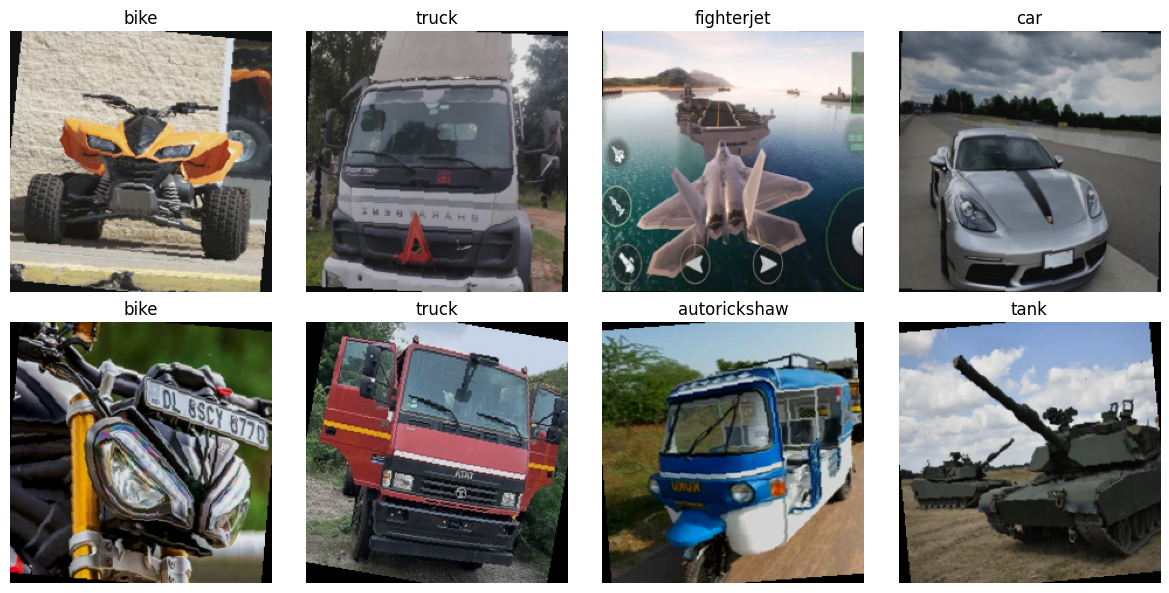

In [8]:
# CELL 8: Visual Checks

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    img = images[i]

    # Convert from [C,H,W] to [H,W,C]
    img = img.permute(1, 2, 0).numpy()

    # Undo normalization for display
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = (img * std) + mean
    img = np.clip(img, 0, 1)

    ax.imshow(img)
    ax.set_title(CLASS_NAMES[labels[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# CELL 9: Load pretrained resnet50

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Replace final classifier
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

# Move model to GPU/CPU
model = model.to(DEVICE)

print(model.fc)
print("Model loaded on:", DEVICE)

Linear(in_features=2048, out_features=6, bias=True)
Model loaded on: cuda


In [10]:
# Freeze entire backbone first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model.fc.parameters():
    param.requires_grad = True

print("Layer4 and classifier head trainable.")

Layer4 and classifier head trainable.


In [11]:
# CELL 11: Loss function and optimizer

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

print("Loss and optimizer configured.")

Loss and optimizer configured.


In [12]:
# CELL 12: Training funtion
def train_one_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(dataloader)
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [13]:
def validate(model, dataloader, loss_fn, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = loss_fn(outputs, labels)

            running_loss += loss.item()

            predictions = torch.argmax(outputs, dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / len(dataloader)
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [ ]:
# CELL 14: Main training loop

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        loss_fn,
        optimizer,
        DEVICE
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        loss_fn,
        DEVICE
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_acc:.2f}%")
    print("-" * 50)

Epoch [1/15]
Train Loss: 1.7264 | Train Accuracy: 32.31%
Val Loss:   1.6763 | Val Accuracy:   42.40%
--------------------------------------------------
Epoch [2/15]
Train Loss: 1.6001 | Train Accuracy: 59.88%
Val Loss:   1.5297 | Val Accuracy:   71.73%
--------------------------------------------------
Epoch [3/15]
Train Loss: 1.4398 | Train Accuracy: 78.48%
Val Loss:   1.3372 | Val Accuracy:   88.00%
--------------------------------------------------
Epoch [4/15]
Train Loss: 1.2399 | Train Accuracy: 87.85%
Val Loss:   1.0900 | Val Accuracy:   92.27%
--------------------------------------------------
Epoch [5/15]
Train Loss: 1.0069 | Train Accuracy: 92.45%
Val Loss:   0.8173 | Val Accuracy:   94.40%
--------------------------------------------------


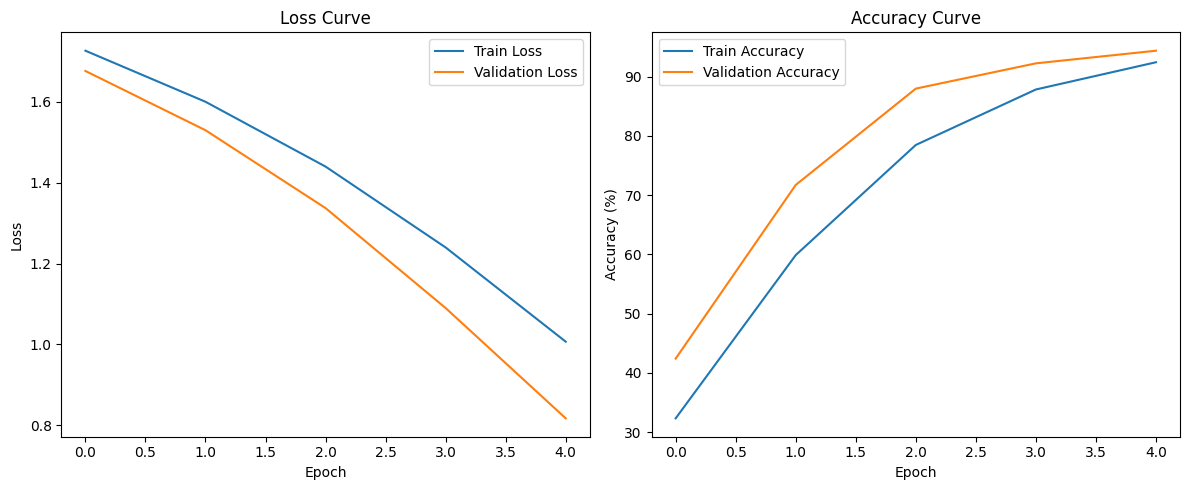

In [15]:
# CELL 15: Plot training curves

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

Test Accuracy: 93.46%

Classification Report:
              precision    recall  f1-score   support

autorickshaw       0.90      0.90      0.90        58
        bike       0.88      0.98      0.93        54
         car       0.90      0.96      0.93        57
  fighterjet       0.99      0.94      0.96        81
        tank       0.98      0.98      0.98        65
       truck       0.93      0.85      0.89        67

    accuracy                           0.93       382
   macro avg       0.93      0.94      0.93       382
weighted avg       0.94      0.93      0.93       382



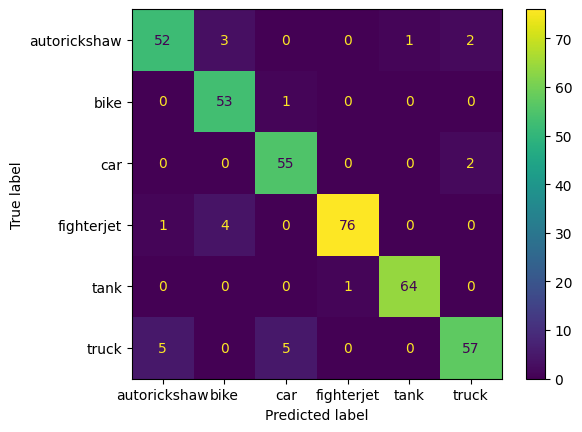

In [16]:
# CELL 16: Test evaluation

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * np.mean(np.array(all_predictions) == np.array(all_labels))

print(f"Test Accuracy: {test_accuracy:.2f}%")

print("\nClassification Report:")
print(classification_report(all_labels, all_predictions, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot()
plt.show()

In [17]:
# CELL 17: Save model

os.makedirs("models", exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "class_names": CLASS_NAMES,
    "num_classes": NUM_CLASSES,
    "image_size": IMAGE_SIZE,
    "architecture": "ResNet50"
}, "models/final_model.pth")

print("Model saved successfully.")

Model saved successfully.
